# Quantum VQC Classifier

Binary classification on the Iris dataset using a Variational Quantum Classifier (VQC)
built with `qiskit-machine-learning`.

This notebook trains the quantum model and saves results to `vqc_results.json`  
for later use in `comparison/comparison.ipynb`.

**How a VQC works (briefly):**  
A VQC is a parameterized quantum circuit split into two parts:
1. **Feature map**: encodes classical input data into quantum states (angles of rotation gates).
2. **Ansatz**: a trainable circuit whose gate angles are optimized during training.

The output is the probability of measuring a certain qubit state, which is mapped to a class label.
Training adjusts the ansatz parameters to minimize a loss function, exactly like gradient descent
in a classical neural network.

**Configuration variable:** `N_FEATURES` controls how many features (and qubits) are used.  
For the 4-feature version, set `N_FEATURES = 4` and results save to `vqc_results_4f.json`.

**Hardware:** Training runs on the Aer simulator. Set `RUN_ON_REAL_HW = True` to evaluate
the trained model on IBM Quantum hardware (requires a valid IBM account configured).

## Imports

In [70]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer.primitives import SamplerV2 as AerSampler

from qiskit_machine_learning.optimizers import SPSA
from qiskit_machine_learning.algorithms import VQC


## Configuration

In [71]:
N_FEATURES      = 2          # 2 or 4 — must match svm.ipynb
TEST_SIZE       = 0.2        # must match svm.ipynb
RANDOM_SEED     = 42         # must match svm.ipynb
MAX_ITER        = 300        # optimizer iterations
N_RUNS          = 3          # independent runs with different initial points
INIT_SEEDS      = [42, 123, 7]  # random seeds for ansatz initialization
RUN_ON_REAL_HW  = False      # set True to evaluate on IBM Quantum after training

RESULTS_FILE = "vqc_results.json" if N_FEATURES == 2 else "vqc_results_4f.json"

print(f"Configuration: N_FEATURES={N_FEATURES}, MAX_ITER={MAX_ITER}, N_RUNS={N_RUNS}, RUN_ON_REAL_HW={RUN_ON_REAL_HW}")
print(f"Results will be saved to: {RESULTS_FILE}")


Configuration: N_FEATURES=2, MAX_ITER=300, N_RUNS=3, RUN_ON_REAL_HW=False
Results will be saved to: vqc_results.json


## Dataset

Identical preprocessing to `svm.ipynb` — same seed, same split, same scaling.
Both models must receive the exact same train/test data for a fair comparison.

**Nota sobre el escalado:** El SVM recibe los datos en `[0, 1]` (MinMaxScaler estándar).
El VQC aplica adicionalmente un factor `× π`, dejando las features en `[0, π]`.
Esto es estándar en VQCs: las puertas de rotación del feature map tienen período `2π`,
por lo que escalar hasta `π` aprovecha la mitad del rango angular sin ambigüedad de fase.
No introduce sesgo comparativo porque ambos modelos ven la misma estructura relativa de los datos.


In [72]:
iris = load_iris()

mask   = iris.target != 0
X_full = iris.data[mask]
y_full = iris.target[mask] - 1      # remap to {0, 1}

if N_FEATURES == 2:
    X = X_full[:, 2:4]
    feature_names = ["petal length", "petal width"]
else:
    X = X_full
    feature_names = list(iris.feature_names)

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Scale to [0, π] so features span the full range of rotation gates
X_scaled_pi = X_scaled * np.pi

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_pi, y_full, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_full
)

print(f"Total samples : {len(X_scaled_pi)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"Features used : {feature_names}")

Total samples : 100
Train samples : 80
Test samples  : 20
Features used : ['petal length', 'petal width']


## Quantum Algorithm — VQC

### Circuit architecture

**Feature map — `ZZFeatureMap`**  
Encodes each input vector into a quantum state using rotation gates (Ry, Rz) and
entangling ZZ interactions. With `reps=2`, the encoding applies twice, increasing
expressiveness. The number of qubits equals `N_FEATURES`.

**Ansatz — `RealAmplitudes`**  
A hardware-efficient variational circuit with Ry rotations and CNOT entangling layers.
With `reps=3`, the circuit has enough parameters to represent complex decision boundaries.
These are the trainable parameters.

**Optimizer — SPSA (Simultaneous Perturbation Stochastic Approximation)**  
A stochastic gradient-free optimizer designed for noisy landscapes. Unlike COBYLA,
which builds a quadratic model of the objective and stops early when the model is flat,
SPSA estimates the gradient via random simultaneous perturbations and runs for the full
`MAX_ITER` iterations. It is the standard choice for variational quantum circuits because
their loss landscapes are non-convex and noisy — exactly the conditions where COBYLA
gets stuck in bad local minima.


Number of qubits         : 2
Feature map depth (reps) : 2
Ansatz depth (reps)      : 3
Trainable parameters     : 8

--- Feature Map ---


/tmp/ipykernel_50976/3818556890.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=n_qubits, reps=2)
/tmp/ipykernel_50976/3818556890.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz      = RealAmplitudes(num_qubits=n_qubits, reps=3)


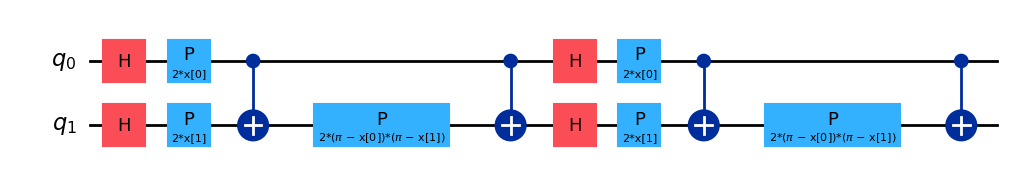


--- Ansatz ---


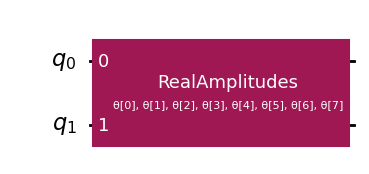

In [73]:
n_qubits    = N_FEATURES
feature_map = ZZFeatureMap(feature_dimension=n_qubits, reps=2)
ansatz      = RealAmplitudes(num_qubits=n_qubits, reps=3)

print(f"Number of qubits         : {n_qubits}")
print(f"Feature map depth (reps) : 2")
print(f"Ansatz depth (reps)      : 3")
print(f"Trainable parameters     : {ansatz.num_parameters}")

print("\n--- Feature Map ---")
display(feature_map.decompose().draw(output="mpl", fold=-1))

print("\n--- Ansatz ---")
display(ansatz.draw(output="mpl", fold=-1))

## Training on Aer Simulator

In [74]:
# ── Single reference run (seed INIT_SEEDS[0]) ──────────────────────────────
loss_history = []

def spsa_callback(nfev, x, fx, dx, is_final):
    loss_history.append(fx)
    if nfev % 30 == 0:
        print(f"  nfev {nfev:>4} | Loss: {fx:.4f}")

backend      = AerSimulator()
pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=1)

rng_ref       = np.random.default_rng(INIT_SEEDS[0])
initial_point = rng_ref.uniform(0, 2 * np.pi, size=ansatz.num_parameters)

ref_optimizer = SPSA(maxiter=MAX_ITER)
vqc = VQC(
    sampler       = AerSampler(),
    feature_map   = deepcopy(feature_map),
    ansatz        = deepcopy(ansatz),
    optimizer     = ref_optimizer,
    pass_manager  = pass_manager,
    initial_point = initial_point,
)
ref_optimizer.callback = spsa_callback

print(f"Training VQC — reference run (seed={INIT_SEEDS[0]}, {MAX_ITER} max iter, SPSA)...")
t0 = time.perf_counter()
vqc.fit(X_train, y_train)
train_time_sim = time.perf_counter() - t0

print(f"\nReference run completed in {train_time_sim:.2f} s")
if loss_history:
    print(f"Final loss: {loss_history[-1]:.4f}")

# ── Multi-seed stability runs ─────────────────────────────────────────────────
print(f"\nRunning {N_RUNS} independent runs with seeds {INIT_SEEDS}...")
run_records = []

for seed in INIT_SEEDS:
    rng  = np.random.default_rng(seed)
    ip   = rng.uniform(0, 2 * np.pi, size=ansatz.num_parameters)
    r_loss = []

    run_opt = SPSA(maxiter=MAX_ITER)
    vqc_r = VQC(
        sampler       = AerSampler(),
        feature_map   = deepcopy(feature_map),
        ansatz        = deepcopy(ansatz),
        optimizer     = run_opt,
        pass_manager  = pass_manager,
        initial_point = ip,
    )
    run_opt.callback = lambda nfev, x, fx, dx, fin, _l=r_loss: _l.append(fx)

    t0 = time.perf_counter()
    vqc_r.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0

    acc_test  = accuracy_score(y_test,  vqc_r.predict(X_test))
    acc_train = accuracy_score(y_train, vqc_r.predict(X_train))
    run_records.append({
        "seed": seed, "acc_test": acc_test, "acc_train": acc_train,
        "time": elapsed, "final_loss": r_loss[-1] if r_loss else None,
        "loss_history": r_loss,
    })
    print(f"  seed={seed:>3} | test={acc_test:.4f}  train={acc_train:.4f}  "
          f"loss={r_loss[-1]:.4f}  time={elapsed:.1f}s")

acc_test_runs  = [r["acc_test"]  for r in run_records]
acc_train_runs = [r["acc_train"] for r in run_records]
acc_test_mean  = float(np.mean(acc_test_runs))
acc_test_std   = float(np.std(acc_test_runs))
acc_train_mean = float(np.mean(acc_train_runs))
acc_train_std  = float(np.std(acc_train_runs))

print(f"\nMulti-seed summary ({N_RUNS} runs):")
print(f"  Test  accuracy : {acc_test_mean:.4f} ± {acc_test_std:.4f}")
print(f"  Train accuracy : {acc_train_mean:.4f} ± {acc_train_std:.4f}")


Training VQC — reference run (seed=42, 300 max iter, SPSA)...
  nfev   30 | Loss: 1.2660
  nfev   60 | Loss: 0.8221
  nfev   90 | Loss: 0.7759
  nfev  120 | Loss: 0.7558
  nfev  150 | Loss: 0.7555
  nfev  180 | Loss: 0.7512
  nfev  210 | Loss: 0.7422
  nfev  240 | Loss: 0.7509
  nfev  270 | Loss: 0.7412
  nfev  300 | Loss: 0.7419
  nfev  330 | Loss: 0.7423
  nfev  360 | Loss: 0.7411
  nfev  390 | Loss: 0.7403
  nfev  420 | Loss: 0.7469
  nfev  450 | Loss: 0.7407
  nfev  480 | Loss: 0.7525
  nfev  510 | Loss: 0.7389
  nfev  540 | Loss: 0.7368
  nfev  570 | Loss: 0.7424
  nfev  600 | Loss: 0.7424
  nfev  630 | Loss: 0.7422
  nfev  660 | Loss: 0.7400
  nfev  690 | Loss: 0.7462
  nfev  720 | Loss: 0.7437
  nfev  750 | Loss: 0.7370
  nfev  780 | Loss: 0.7374
  nfev  810 | Loss: 0.7439
  nfev  840 | Loss: 0.7483
  nfev  870 | Loss: 0.7408
  nfev  900 | Loss: 0.7434

Reference run completed in 232.41 s
Final loss: 0.7434

Running 3 independent runs with seeds [42, 123, 7]...
  seed= 42 | test

## Evaluation on Simulator

In [75]:
y_pred_train_sim = vqc.predict(X_train)
y_pred_test_sim  = vqc.predict(X_test)

acc_train_sim = accuracy_score(y_train, y_pred_train_sim)
acc_test_sim  = accuracy_score(y_test,  y_pred_test_sim)

print("Reference run (single seed):")
print(f"  Train accuracy : {acc_train_sim:.4f}")
print(f"  Test  accuracy : {acc_test_sim:.4f}")
print()
print(f"Multi-seed mean ± std ({N_RUNS} runs):")
print(f"  Test  accuracy : {acc_test_mean:.4f} ± {acc_test_std:.4f}")
print(f"  Train accuracy : {acc_train_mean:.4f} ± {acc_train_std:.4f}")
print()
print(classification_report(y_test, y_pred_test_sim,
                             target_names=["Versicolor", "Virginica"]))


Reference run (single seed):
  Train accuracy : 0.7625
  Test  accuracy : 0.7000

Multi-seed mean ± std (3 runs):
  Test  accuracy : 0.7000 ± 0.0000
  Train accuracy : 0.7708 ± 0.0156

              precision    recall  f1-score   support

  Versicolor       0.70      0.70      0.70        10
   Virginica       0.70      0.70      0.70        10

    accuracy                           0.70        20
   macro avg       0.70      0.70      0.70        20
weighted avg       0.70      0.70      0.70        20



## Evaluation on IBM Quantum Hardware (optional)

The model is **trained** on the simulator and **evaluated** on real hardware.
This avoids the prohibitive queue time of running hundreds of training iterations
on real hardware, while still showing how noise affects inference.

Set `RUN_ON_REAL_HW = True` in the Configuration cell to enable this section.

In [76]:
acc_test_real    = None
y_pred_test_real = None
backend_name     = None
circuit_depth_real = None

if RUN_ON_REAL_HW:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RealSampler
    from qiskit_ibm_runtime.fake_provider import FakeProviderForBackendV2
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False,
                                  min_num_qubits=n_qubits)
    backend_name = backend.name
    print(f"Using backend: {backend_name}")

    # Build the full VQC inference circuit with trained weights bound
    # and transpile it to the real hardware topology
    real_sampler = RealSampler(backend)

    vqc_real = VQC(
        sampler     = real_sampler,
        feature_map = feature_map,
        ansatz      = ansatz,
    )
    # Transfer trained weights
    vqc_real.weights = vqc.weights

    print("Running inference on real hardware...")
    t0 = time.perf_counter()
    y_pred_test_real = vqc_real.predict(X_test)
    infer_time_real  = time.perf_counter() - t0

    acc_test_real = accuracy_score(y_test, y_pred_test_real)
    print(f"Test accuracy (real HW): {acc_test_real:.4f}")
    print(f"Inference time        : {infer_time_real:.2f} s")
else:
    print("RUN_ON_REAL_HW is False — skipping real hardware evaluation.")
    print("Set RUN_ON_REAL_HW = True in the Configuration cell to enable.")

RUN_ON_REAL_HW is False — skipping real hardware evaluation.
Set RUN_ON_REAL_HW = True in the Configuration cell to enable.


## Plots

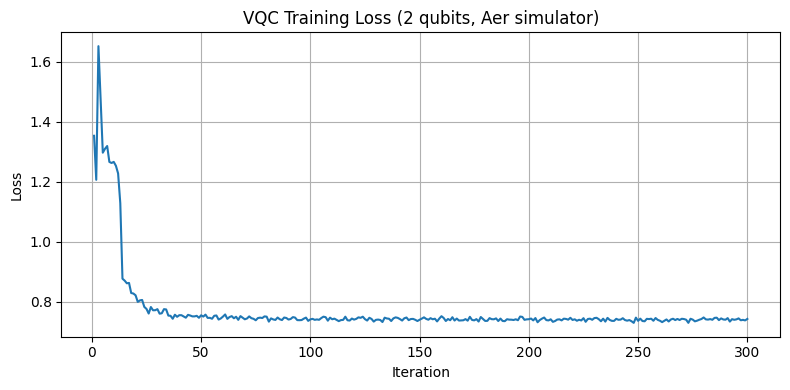

In [77]:
# --- Loss curve ---
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, color="tab:blue")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title(f"VQC Training Loss ({N_FEATURES} qubits, Aer simulator)")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"vqc_loss_curve{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

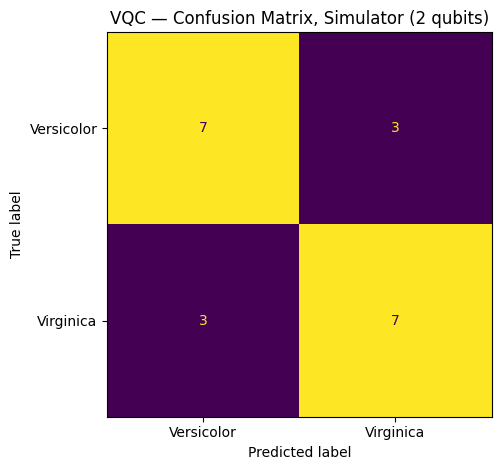

In [78]:
# --- Confusion matrix (simulator) ---
cm = confusion_matrix(y_test, y_pred_test_sim)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Versicolor", "Virginica"])
disp.plot(colorbar=False)
plt.title(f"VQC — Confusion Matrix, Simulator ({N_FEATURES} qubits)")
plt.tight_layout()
plt.savefig(f"vqc_confusion_matrix_sim{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

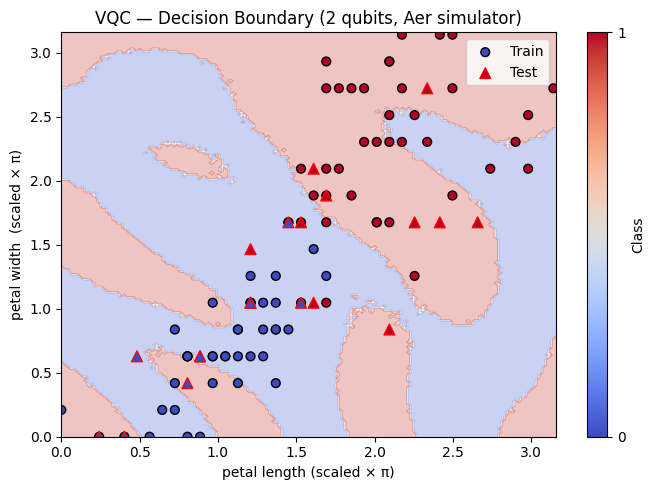

In [79]:
# --- Decision boundary (only for 2 features) ---
if N_FEATURES == 2:
    h = 0.02
    xx, yy = np.meshgrid(np.arange(0, np.pi + h, h), np.arange(0, np.pi + h, h))
    grid   = np.c_[xx.ravel(), yy.ravel()]
    Z      = vqc.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
                          cmap="coolwarm", edgecolors="k", s=40, label="Train")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test,
                cmap="coolwarm", edgecolors="r", s=60, marker="^", label="Test")
    plt.colorbar(scatter, ticks=[0, 1], label="Class")
    plt.xlabel("petal length (scaled × π)")
    plt.ylabel("petal width  (scaled × π)")
    plt.title("VQC — Decision Boundary (2 qubits, Aer simulator)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("vqc_decision_boundary.png", dpi=150)
    plt.show()
else:
    print("Decision boundary plot skipped (only available for N_FEATURES=2).")

## Save Results

In [80]:
results = {
    # --- Experiment metadata ---
    "model"              : "VQC",
    "n_features"         : N_FEATURES,
    "n_qubits"           : n_qubits,
    "feature_names"      : feature_names,
    "n_train"            : int(len(X_train)),
    "n_test"             : int(len(X_test)),
    "random_seed"        : RANDOM_SEED,
    # --- Circuit architecture ---
    "feature_map"        : "ZZFeatureMap",
    "feature_map_reps"   : 2,
    "ansatz"             : "RealAmplitudes",
    "ansatz_reps"        : 3,
    "n_parameters"       : int(ansatz.num_parameters),
    "optimizer"          : "SPSA",
    "max_iter"           : MAX_ITER,
    # --- Timing ---
    "train_time_sim_s"   : float(train_time_sim),
    # --- Accuracy reference run ---
    "accuracy_test_sim"  : float(acc_test_sim),
    "accuracy_train_sim" : float(acc_train_sim),
    # --- Multi-seed stability ---
    "n_runs"             : N_RUNS,
    "init_seeds"         : INIT_SEEDS,
    "accuracy_test_runs" : [float(a) for a in acc_test_runs],
    "accuracy_test_mean" : acc_test_mean,
    "accuracy_test_std"  : acc_test_std,
    "accuracy_train_runs": [float(a) for a in acc_train_runs],
    "accuracy_train_mean": acc_train_mean,
    "accuracy_train_std" : acc_train_std,
    # --- Loss history (reference run) ---
    "loss_history"       : [float(l) for l in loss_history],
    # --- Predictions (reference run) ---
    "y_test"             : y_test.tolist(),
    "y_pred_test_sim"    : y_pred_test_sim.tolist(),
    # --- Real hardware (filled only if RUN_ON_REAL_HW=True) ---
    "real_hw_run"        : RUN_ON_REAL_HW,
    "backend_name"       : backend_name,
    "accuracy_test_real" : float(acc_test_real) if acc_test_real is not None else None,
    "y_pred_test_real"   : y_pred_test_real.tolist() if y_pred_test_real is not None else None,
}

with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_FILE}")
skip = {"loss_history", "y_test", "y_pred_test_sim", "y_pred_test_real", "accuracy_test_runs", "accuracy_train_runs"}
print(json.dumps({k: v for k, v in results.items() if k not in skip}, indent=2))


Results saved to vqc_results.json
{
  "model": "VQC",
  "n_features": 2,
  "n_qubits": 2,
  "feature_names": [
    "petal length",
    "petal width"
  ],
  "n_train": 80,
  "n_test": 20,
  "random_seed": 42,
  "feature_map": "ZZFeatureMap",
  "feature_map_reps": 2,
  "ansatz": "RealAmplitudes",
  "ansatz_reps": 3,
  "n_parameters": 8,
  "optimizer": "SPSA",
  "max_iter": 300,
  "train_time_sim_s": 232.40841847299998,
  "accuracy_test_sim": 0.7,
  "accuracy_train_sim": 0.7625,
  "n_runs": 3,
  "init_seeds": [
    42,
    123,
    7
  ],
  "accuracy_test_mean": 0.6999999999999998,
  "accuracy_test_std": 1.1102230246251565e-16,
  "accuracy_train_mean": 0.7708333333333334,
  "accuracy_train_std": 0.015590239111558084,
  "real_hw_run": false,
  "backend_name": null,
  "accuracy_test_real": null
}
